In [ ]:
## 1. Title
# AI Job Market Intelligence 2026

### Automation vs Traditional Roles — Skills, Salaries, Demand & Market Trends

#Project Type:** Data Analytics
#Dataset Source:** Kaggle
#Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn
#Platform:** Google Colab

# 2. Introduction

The job market is rapidly changing due to the adoption of Artificial Intelligence,
automation, and emerging technologies.

This project analyzes job market data to understand the demand for AI-related
and traditional roles, required skills, salary patterns, experience requirements,
employment types, and geographical trends.

The analysis aims to provide data-driven insights into the changing IT and
technology job market.

# 3. Business Questions

This project attempts to answer the following questions:

1. What types of jobs are most common in the dataset?
2. Which skills are most frequently demanded?
3. How does demand differ between AI-related and traditional roles?
4. What is the salary distribution across job roles?
5. Which countries or regions have higher job demand?
6. How does experience level affect salary?
7. What employment types are most common?
8. Which technology skills are becoming important in the job market?
9. What patterns can be observed between job roles, skills, experience, and salary?

## 4. Importing Required Libraries

The following Python libraries are used for data analysis and visualization:

- Pandas: Data manipulation and analysis
- NumPy: Numerical operations
- Matplotlib: Data visualization
- Seaborn: Statistical visualization

# 5. Dataset Loading

In this step, the job market dataset is loaded into a Pandas DataFrame using the `read_csv()` function.

The dataset is then inspected using the `head()` function to understand its structure and the type of information available.

The loaded dataset is used for further data cleaning, exploratory data analysis, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/ai_job_market_dataset.csv')

df.head()

,search_keyword,search_country,id,title,company,location,category,contract_type,contract_time,salary_min,salary_max,salary_is_predicted,created,description,is_ai_related,salary_avg,created_date,currency,country_name
0,artificial intelligence,gb,5822242641,Senior Technologist Artificial Intelligence R ...,Hackajob Ltd,"Great Baddow, Chelmsford",Engineering Jobs,permanent,NaN,40000.00,40000.00,0,2026-07-31 11:09:48+00:00,hackajob is partnering directly with BAE Syste...,True,40000.00,2026-07-31,GBP,United Kingdom
1,artificial intelligence,gb,5727313687,Artificial Intelligence,Adria Solutions,"Altrincham, Greater Manchester",IT Jobs,NaN,NaN,53702.83,53702.83,1,2026-05-12 22:05:22+00:00,AI Engineer - Manchester - Circa £50K Our clie...,True,53702.83,2026-05-12,GBP,United Kingdom
2,artificial intelligence,gb,5736675451,Artificial Intelligence Engineer,Oxford Dynamics,UK,IT Jobs,permanent,full_time,74422.25,74422.25,1,2026-05-21 21:07:04+00:00,Artificial Intelligence Engineers Contract: Pe...,True,74422.25,2026-05-21,GBP,United Kingdom
3,artificial intelligence,gb,5824444000,Artificial Intelligence Engineer,Quantiphi,"London, UK",IT Jobs,NaN,full_time,53031.54,53031.54,1,2026-08-01 18:29:25+00:00,"While technology is the heart of our business,...",True,53031.54,2026-08-01,GBP,United Kingdom
4,artificial intelligence,gb,5844156514,Artificial Intelligence Engineer,Discover International,"Monument, Central London",IT Jobs,contract,full_time,52000.00,60000.00,0,2026-08-16 11:39:19+00:00,"Salary: £52,000 - 60,000 per year Requirements...",True,56000.00,2026-08-16,GBP,United Kingdom


## 6. Dataset Information

In this step, we examine the structure of the dataset, including the number
of rows and columns, data types, and other basic information.

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1696
Number of Columns: 19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   search_keyword       1696 non-null   object 
 1   search_country       1696 non-null   object 
 2   id                   1696 non-null   int64  
 3   title                1696 non-null   object 
 4   company              1695 non-null   object 
 5   location             1696 non-null   object 
 6   category             1696 non-null   object 
 7   contract_type        432 non-null    object 
 8   contract_time        826 non-null    object 
 9   salary_min           1513 non-null   float64
 10  salary_max           1513 non-null   float64
 11  salary_is_predicted  1696 non-null   int64  
 12  created              1696 non-null   object 
 13  description          1696 non-null   object 
 14  is_ai_related        1696 non-null   bool   
 15  salary_avg           1513 non-null   f

In [ ]:
df.columns.tolist()

['search_keyword',
 'search_country',
 'id',
 'title',
 'company',
 'location',
 'category',
 'contract_type',
 'contract_time',
 'salary_min',
 'salary_max',
 'salary_is_predicted',
 'created',
 'description',
 'is_ai_related',
 'salary_avg',
 'created_date',
 'currency',
 'country_name']

# 7. Data Cleaning

Data cleaning is an important step before performing analysis. In this stage,
we check for missing values, duplicate records, incorrect data types, and
other data quality issues.

The cleaned data will then be used for further analysis and visualization.

In [ ]:
df.isnull().sum()

,0
search_keyword,0
search_country,0
id,0
title,0
company,1
location,0
category,0
contract_type,1264
contract_time,870
salary_min,183


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.dtypes

,0
search_keyword,object
search_country,object
id,int64
title,object
company,object
location,object
category,object
contract_type,object
contract_time,object
salary_min,float64


## 7.1 Handling Missing Values

The dataset contains missing values in a few columns. Instead of removing
large numbers of records, appropriate techniques are used to preserve the
available information.

Categorical missing values are replaced with "Unknown". Missing average
salary values are calculated from the available minimum and maximum salary
where possible.

In [ ]:
# Fill missing categorical values
df['company'] = df['company'].fillna('Unknown')
df['contract_type'] = df['contract_type'].fillna('Unknown')
df['contract_time'] = df['contract_time'].fillna('Unknown')

# Calculate missing average salary using minimum and maximum salary
df['salary_avg'] = df['salary_avg'].fillna(
    (df['salary_min'] + df['salary_max']) / 2
)

# Check remaining missing values
df.isnull().sum()

,0
search_keyword,0
search_country,0
id,0
title,0
company,0
location,0
category,0
contract_type,0
contract_time,0
salary_min,183


## 7.2 Verification After Cleaning

After handling the missing values, the dataset is checked again to verify
that the cleaning process was successful.

In [ ]:
print("Total duplicate rows:", df.duplicated().sum())
print("\nRemaining missing values:")
print(df.isnull().sum())

Total duplicate rows: 0

Remaining missing values:
search_keyword           0
search_country           0
id                       0
title                    0
company                  0
location                 0
category                 0
contract_type            0
contract_time            0
salary_min             183
salary_max             183
salary_is_predicted      0
created                  0
description              0
is_ai_related            0
salary_avg             183
created_date             0
currency                 0
country_name             0
dtype: int64


## 7.3 Final Data Cleaning Check

Salary-related fields contain some missing values because salary information
is not available for every job posting. These records will be retained in
the dataset and excluded only when performing salary-specific analysis.

No duplicate records were found in the dataset.

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values:
search_keyword           0
search_country           0
id                       0
title                    0
company                  0
location                 0
category                 0
contract_type            0
contract_time            0
salary_min             183
salary_max             183
salary_is_predicted      0
created                  0
description              0
is_ai_related            0
salary_avg             183
created_date             0
currency                 0
country_name             0
dtype: int64


# 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the major
patterns and trends in the job market dataset.

The analysis focuses on AI-related jobs, job categories, countries,
employment types, and salary patterns.

## 8.1 AI-Related vs Traditional Jobs

This analysis compares AI-related job postings with traditional job
postings to understand the level of AI adoption in the job market.

In [ ]:
ai_counts = df['is_ai_related'].value_counts()

print(ai_counts)

is_ai_related
True     1021
False     675
Name: count, dtype: int64


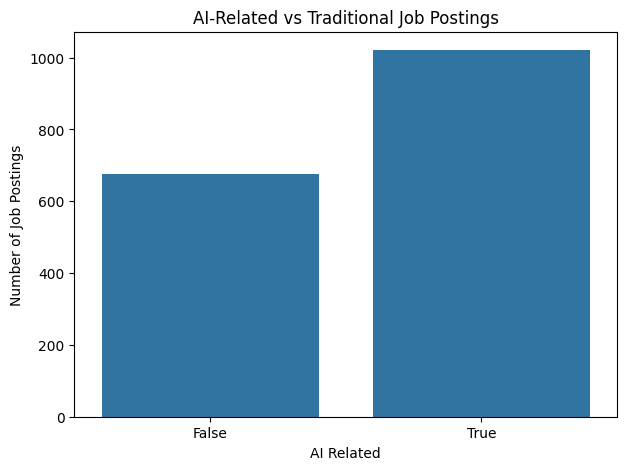

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='is_ai_related')

plt.title('AI-Related vs Traditional Job Postings')
plt.xlabel('AI Related')
plt.ylabel('Number of Job Postings')

plt.show()

## 8.2 Percentage of AI-Related Jobs

The percentage of AI-related and traditional job postings is calculated
to understand their proportion within the overall dataset.

In [ ]:
ai_percentage = df['is_ai_related'].value_counts(normalize=True) * 100

print(ai_percentage.round(2))

is_ai_related
True     60.2
False    39.8
Name: proportion, dtype: float64


## 8.3 Job Category Distribution

This analysis examines the distribution of job postings across different job
categories to identify which areas have the highest demand.

In [ ]:
category_counts = df['category'].value_counts()

print(category_counts)

category
IT Jobs                             695
Engineering Jobs                    237
Admin Jobs                          202
Customer Services Jobs              153
Sales Jobs                          133
Accounting & Finance Jobs            59
Teaching Jobs                        31
Scientific & QA Jobs                 31
Part time Jobs                       28
Maintenance Jobs                     26
Legal Jobs                           19
Healthcare & Nursing Jobs            13
PR, Advertising & Marketing Jobs     11
Graduate Jobs                        10
HR & Recruitment Jobs                 9
Trade & Construction Jobs             8
Manufacturing Jobs                    7
Retail Jobs                           7
Logistics & Warehouse Jobs            6
Consultancy Jobs                      5
Hospitality & Catering Jobs           3
Creative & Design Jobs                2
Social work Jobs                      1
Name: count, dtype: int64


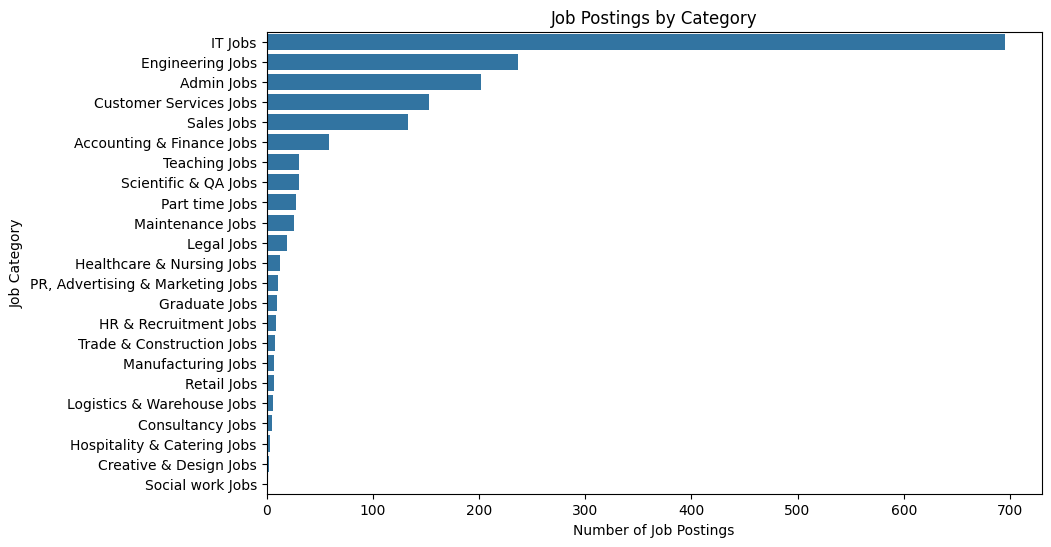

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title('Job Postings by Category')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Category')

plt.show()

## 8.4 Job Postings by Company

This analysis identifies companies with the highest number of job postings
in the dataset.

In [ ]:
company_counts = df['company'].value_counts().head(10)

print(company_counts)

company
Bespoke Labs           112
EE                     111
Maximus                 71
Concentrix              44
Teleperformance         34
Robert Half             32
Capital One             26
A&O Shearman            20
Booz Allen Hamilton     19
GEICO                   17
Name: count, dtype: int64


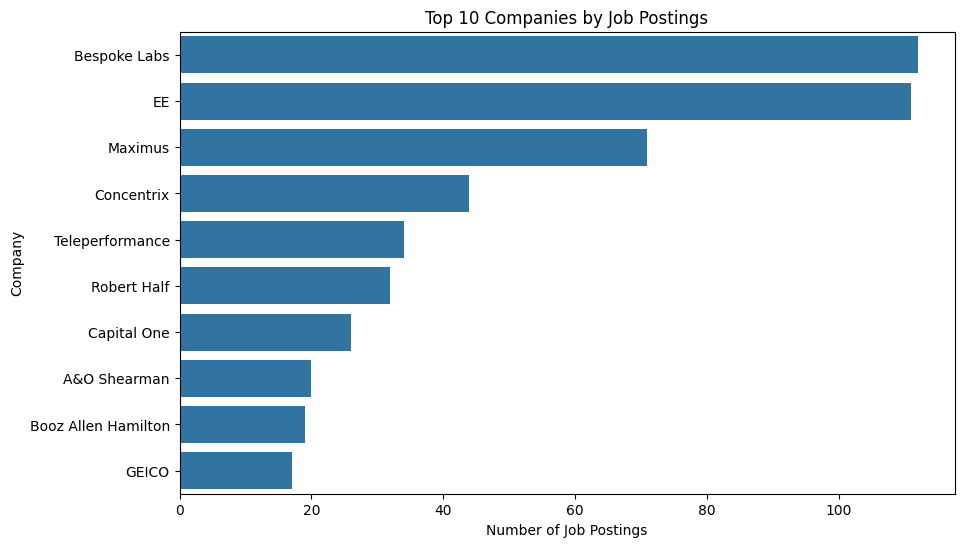

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title('Top 10 Companies by Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Company')

plt.show()

## 8.5 Job Postings by Country

This analysis examines the distribution of job postings across different
countries to understand the geographical spread of the job market.

In [ ]:
country_counts = df['country_name'].value_counts()

print(country_counts)

country_name
United States     750
United Kingdom    746
India             200
Name: count, dtype: int64


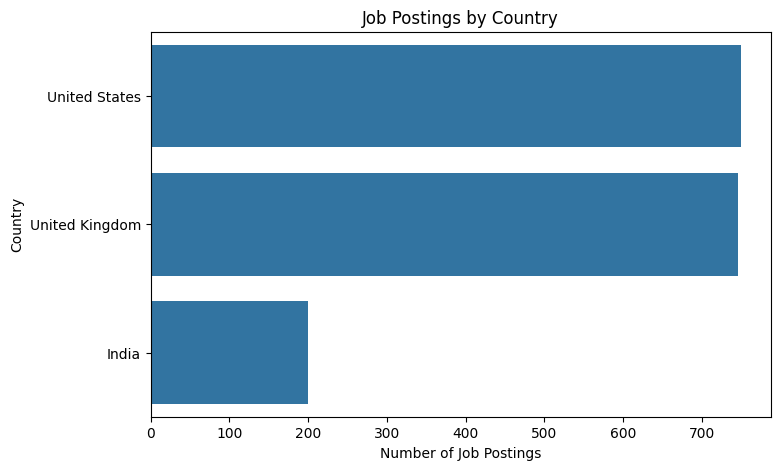

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title('Job Postings by Country')
plt.xlabel('Number of Job Postings')
plt.ylabel('Country')

plt.show()

## 8.6 Employment Type Analysis

This analysis examines the distribution of job postings based on employment
type to understand the most common employment arrangements.

In [ ]:
employment_counts = df['contract_time'].value_counts()

print(employment_counts)

contract_time
Unknown      870
full_time    685
part_time    141
Name: count, dtype: int64


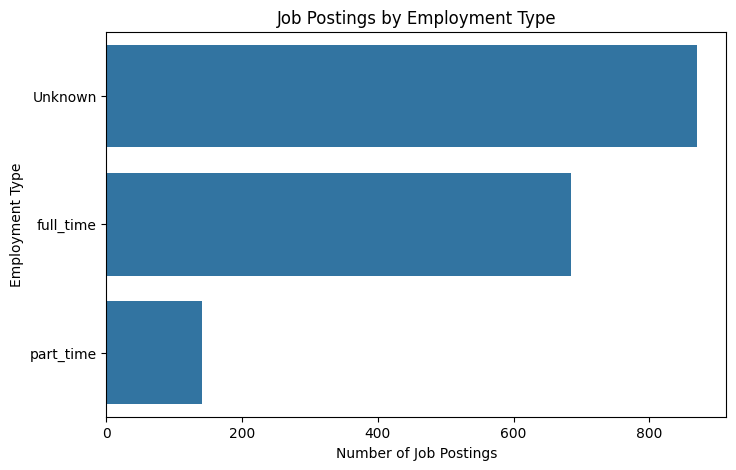

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    y='contract_time',
    order=df['contract_time'].value_counts().index
)

plt.title('Job Postings by Employment Type')
plt.xlabel('Number of Job Postings')
plt.ylabel('Employment Type')

plt.show()

## 8.7 Salary Analysis

Salary is an important factor in understanding job market trends. This
analysis examines salary ranges and average salary values available in
the dataset.

Salary analysis is performed with consideration of the currency associated
with each job posting.

In [ ]:
print(df[['salary_min', 'salary_max', 'salary_avg', 'currency']].describe())

         salary_min    salary_max    salary_avg
count  1.513000e+03  1.513000e+03  1.513000e+03
mean   7.729904e+04  8.727796e+04  8.228850e+04
std    9.713633e+04  1.836966e+05  1.375764e+05
min    0.000000e+00  1.300000e+01  1.300000e+01
25%    3.488679e+04  3.504305e+04  3.500000e+04
50%    5.460000e+04  5.514576e+04  5.500000e+04
75%    9.760078e+04  1.000000e+05  9.896877e+04
max    2.000000e+06  5.000000e+06  3.500000e+06


In [ ]:
print(df['currency'].value_counts())

currency
USD    750
GBP    746
INR    200
Name: count, dtype: int64


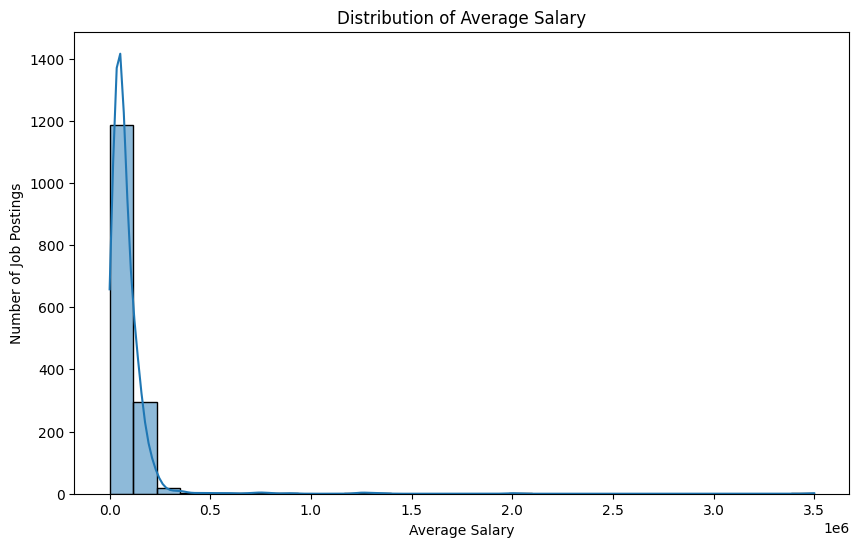

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='salary_avg',
    bins=30,
    kde=True
)

plt.title('Distribution of Average Salary')
plt.xlabel('Average Salary')
plt.ylabel('Number of Job Postings')

plt.show()

In [ ]:
df['currency'].value_counts()

,count
currency,
USD,750
GBP,746
INR,200


In [ ]:
df.groupby('currency')['salary_avg'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

,count,mean,median,min,max
currency,,,,,
GBP,746,48866.61,44631.23,13.0,188500.0
INR,17,992941.18,750000.00,50000.0,3500000.0
USD,750,94890.68,78710.35,32.0,478168.2


## 8.8 AI-Related vs Traditional Jobs — Salary Analysis

This analysis compares the average salary of AI-related and traditional job
postings within each currency.

Since the dataset contains multiple currencies, salaries are analyzed
separately by currency to avoid misleading comparisons.

In [ ]:
salary_by_ai = df.groupby(
    ['currency', 'is_ai_related']
)['salary_avg'].agg(['count', 'mean', 'median']).round(2)

salary_by_ai

count       mean     median
currency is_ai_related                             
GBP      False            341   31702.73   27091.05
         True             405   63318.17   57500.00
INR      False              0        NaN        NaN
         True              17  992941.18  750000.00
USD      False            301   43466.04   40624.72
         True             449  129364.67  124965.99

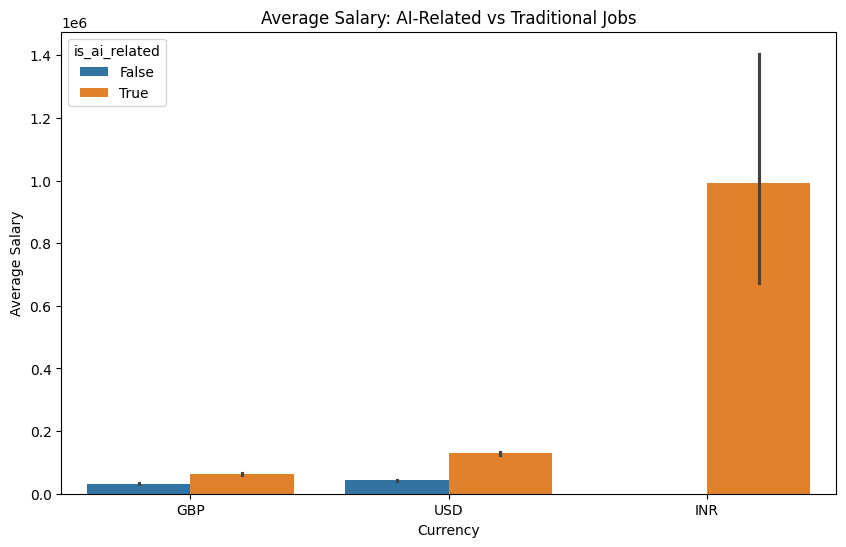

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='currency',
    y='salary_avg',
    hue='is_ai_related'
)

plt.title('Average Salary: AI-Related vs Traditional Jobs')
plt.xlabel('Currency')
plt.ylabel('Average Salary')

plt.show()

## 8.9 Most Demanded Job Keywords

Job search keywords provide an indication of the types of roles and
technologies that are most frequently represented in the dataset.

This analysis identifies the most common search keywords in the job market.

In [ ]:
keyword_counts = df['search_keyword'].value_counts().head(15)

print(keyword_counts)

search_keyword
artificial intelligence    450
automation                 348
data entry                 300
customer service           300
machine learning           298
Name: count, dtype: int64


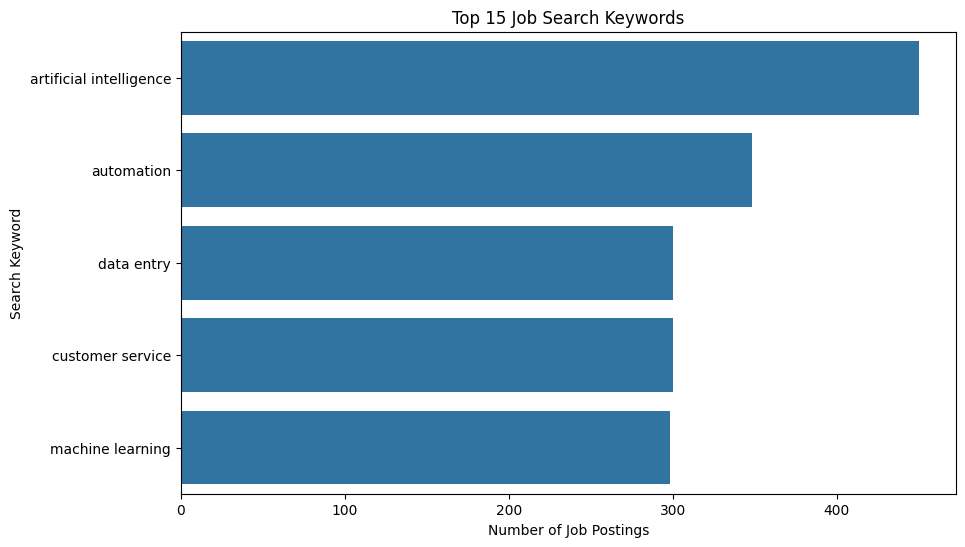

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=keyword_counts.values,
    y=keyword_counts.index
)

plt.title('Top 15 Job Search Keywords')
plt.xlabel('Number of Job Postings')
plt.ylabel('Search Keyword')

plt.show()

## 8.10 Job Location Analysis

This analysis examines the locations associated with job postings to
identify areas with a higher concentration of opportunities.

In [ ]:
location_counts = df['location'].value_counts().head(15)

print(location_counts)

location
London, UK                       145
UK                                54
India                             44
Bangalore, Karnataka              38
Belfast, Northern Ireland         23
US                                21
Pimmit, Fairfax County            19
Grand Central, Manhattan          18
Hyderabad, Telangana              15
Mumbai, Maharashtra               13
Chennai, Tamil Nadu               10
South East London, London          9
Prince, Manhattan                  8
Hillhead, Glasgow City Centre      8
Ahmedabad, Gujarat                 8
Name: count, dtype: int64


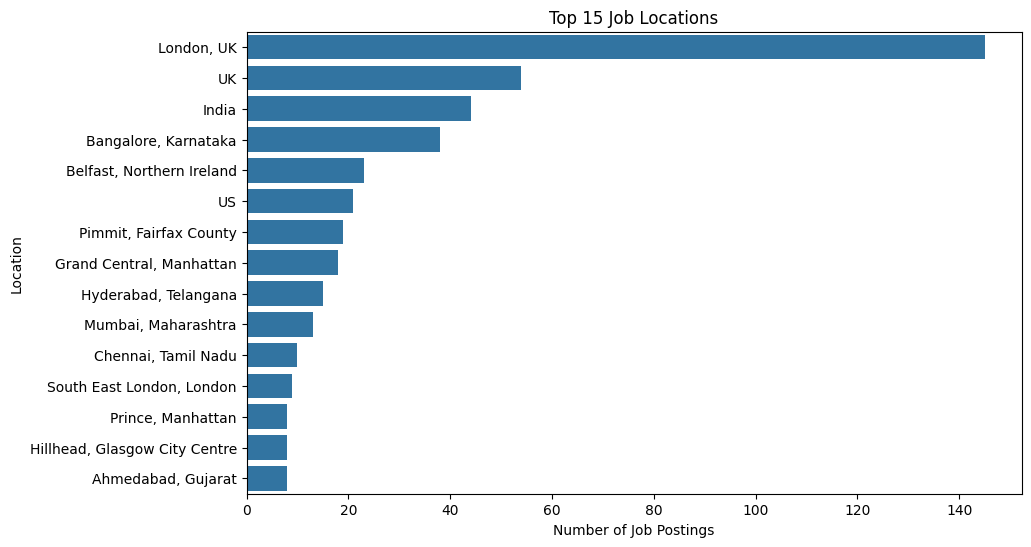

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=location_counts.values,
    y=location_counts.index
)

plt.title('Top 15 Job Locations')
plt.xlabel('Number of Job Postings')
plt.ylabel('Location')

plt.show()

## 8.11 Skills Analysis

Job descriptions contain valuable information about the skills and technologies
expected by employers.

In this analysis, frequently mentioned technical skills are identified from
job descriptions to understand the most demanded skills in the job market.

In [ ]:
import re

skill_patterns = {
    'Python': r'\bpython\b',
    'SQL': r'\bsql\b',
    'Excel': r'\bexcel\b',
    'Power BI': r'\bpower\s*bi\b',
    'Tableau': r'\btableau\b',
    'Machine Learning': r'\bmachine learning\b',
    'Artificial Intelligence': r'\bartificial intelligence\b',
    'Deep Learning': r'\bdeep learning\b',
    'AWS': r'\baws\b',
    'Azure': r'\bazure\b',
    'Google Cloud': r'\bgoogle cloud\b',
    'Java': r'\bjava\b',
    'JavaScript': r'\bjavascript\b',
    'C++': r'\bc\+\+\b',
    'R': r'(?<![A-Za-z])R(?![A-Za-z])',
    'Docker': r'\bdocker\b',
    'Kubernetes': r'\bkubernetes\b',
    'Git': r'\bgit\b',
    'TensorFlow': r'\btensorflow\b',
    'PyTorch': r'\bpytorch\b'
}

skill_counts = {}

for skill, pattern in skill_patterns.items():
    skill_counts[skill] = df['description'].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    ).sum()

skill_counts = pd.Series(skill_counts).sort_values(ascending=False)

print(skill_counts)

Artificial Intelligence    176
Machine Learning           165
R                           46
Python                      19
Excel                       13
Azure                       12
AWS                         11
Deep Learning               11
PyTorch                      7
Java                         7
SQL                          6
TensorFlow                   5
Google Cloud                 4
Kubernetes                   2
Docker                       1
JavaScript                   1
Power BI                     0
Tableau                      0
C++                          0
Git                          0
dtype: int64


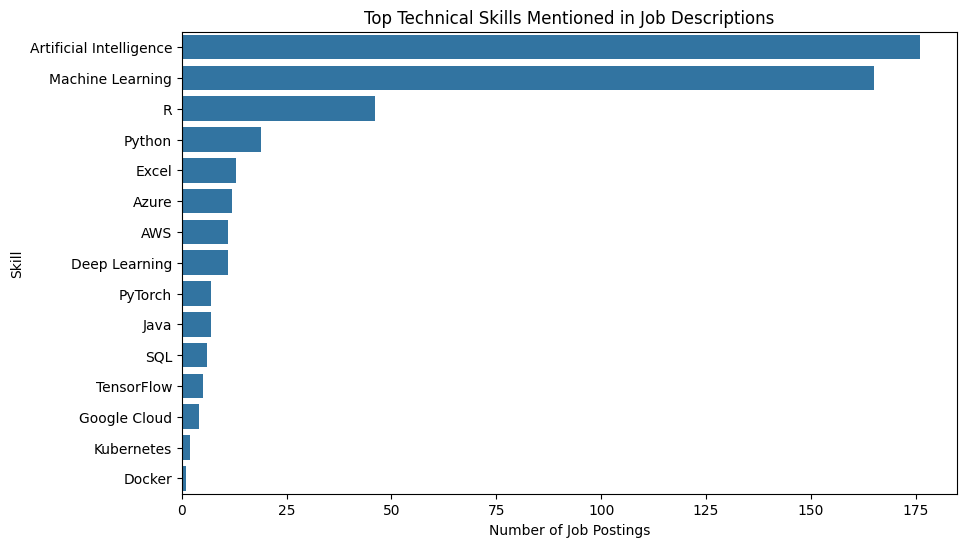

In [ ]:
top_skills = skill_counts[skill_counts > 0].head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.title('Top Technical Skills Mentioned in Job Descriptions')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')

plt.show()

## 8.12 Skill Demand: AI-Related vs Traditional Jobs

This analysis compares the frequency of selected technical skills between
AI-related and traditional job postings.

The comparison helps identify which technologies are more commonly associated
with AI-related roles.

In [ ]:
ai_skill_counts = {}

for skill, pattern in skill_patterns.items():
    if skill == 'R':
        continue

    ai_skill_counts[skill] = {
        'AI-Related': df.loc[
            df['is_ai_related'] == True, 'description'
        ].str.contains(pattern, case=False, na=False, regex=True).sum(),

        'Traditional': df.loc[
            df['is_ai_related'] == False, 'description'
        ].str.contains(pattern, case=False, na=False, regex=True).sum()
    }

ai_skill_df = pd.DataFrame(ai_skill_counts).T

ai_skill_df = ai_skill_df.sort_values(
    by='AI-Related',
    ascending=False
)

ai_skill_df

,AI-Related,Traditional
Artificial Intelligence,176,0
Machine Learning,165,0
Python,18,1
Deep Learning,11,0
AWS,10,1
Azure,10,2
PyTorch,7,0
Java,6,1
TensorFlow,5,0
Google Cloud,4,0


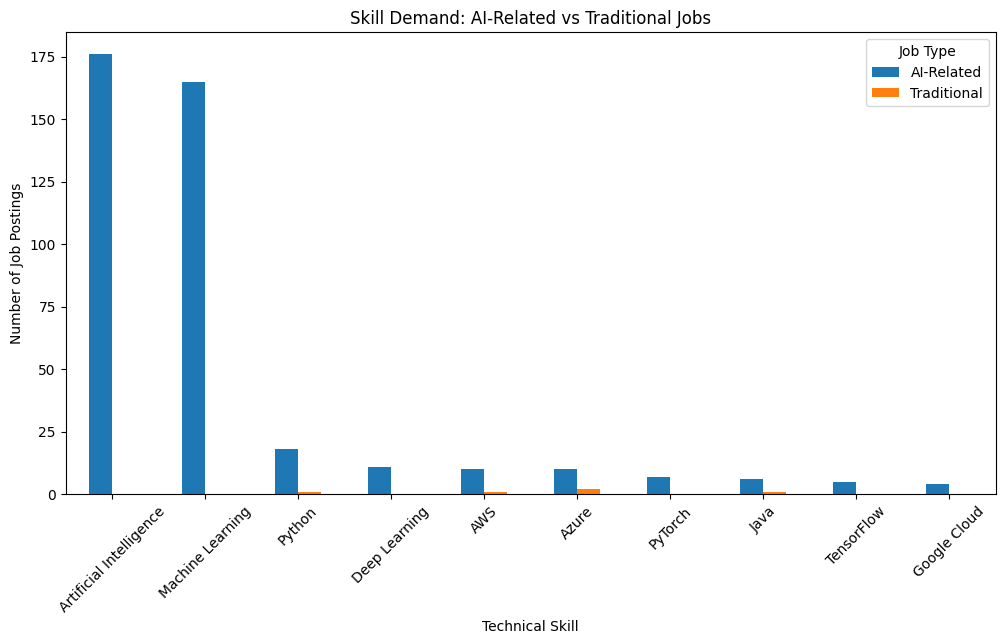

In [ ]:
ai_skill_df.head(10).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Skill Demand: AI-Related vs Traditional Jobs')
plt.xlabel('Technical Skill')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.legend(title='Job Type')

plt.show()

## 9. Key Findings - Values

In [ ]:
# ==========================================
# KEY FINDINGS - DATA SUMMARY
# ==========================================

print("========== DATASET SUMMARY ==========")
print("Total Job Postings:", len(df))

# AI vs Traditional
ai_counts = df['is_ai_related'].value_counts(dropna=False)
print("\n========== AI vs TRADITIONAL ==========")
print(ai_counts)

ai_percentage = df['is_ai_related'].mean() * 100
print(f"AI-related Jobs: {ai_percentage:.2f}%")
print(f"Traditional Jobs: {100 - ai_percentage:.2f}%")

# Job Category
print("\n========== TOP JOB CATEGORIES ==========")
print(df['category'].value_counts().head(5))

# Companies
print("\n========== TOP COMPANIES ==========")
print(df['company'].value_counts().head(5))

# Countries
print("\n========== TOP COUNTRIES ==========")
print(df['country_name'].value_counts().head(5))

# Employment Type
print("\n========== EMPLOYMENT TYPES ==========")
print(df['contract_type'].value_counts().head(10))

# Salary
print("\n========== SALARY ANALYSIS ==========")
print("Average Salary:", df['salary_avg'].mean())
print("Median Salary:", df['salary_avg'].median())
print("Minimum Salary:", df['salary_avg'].min())
print("Maximum Salary:", df['salary_avg'].max())

# AI vs Traditional Salary
print("\n========== AI vs TRADITIONAL SALARY ==========")
print(
    df.groupby('is_ai_related')['salary_avg']
      .agg(['count', 'mean', 'median'])
      .round(2)
)

# Job Locations
print("\n========== TOP JOB LOCATIONS ==========")
print(df['location'].value_counts().head(5))

# Search Keywords
print("\n========== TOP SEARCH KEYWORDS ==========")
print(df['search_keyword'].value_counts().head(10))

========== DATASET SUMMARY ==========
Total Job Postings: 1696

========== AI vs TRADITIONAL ==========
is_ai_related
True     1021
False     675
Name: count, dtype: int64
AI-related Jobs: 60.20%
Traditional Jobs: 39.80%

========== TOP JOB CATEGORIES ==========
category
IT Jobs                   695
Engineering Jobs          237
Admin Jobs                202
Customer Services Jobs    153
Sales Jobs                133
Name: count, dtype: int64

========== TOP COMPANIES ==========
company
Bespoke Labs       112
EE                 111
Maximus             71
Concentrix          44
Teleperformance     34
Name: count, dtype: int64

========== TOP COUNTRIES ==========
country_name
United States     750
United Kingdom    746
India             200
Name: count, dtype: int64

========== EMPLOYMENT TYPES ==========
contract_type
Unknown      1264
permanent     289
contract      143
Name: count, dtype: int64

========== SALARY ANALYSIS ==========
Average Salary: 82288.50109715796
Median Salary: 55

## 10. Key Findings and Insights

The analysis of 1,696 job postings provides several important insights into the
AI-driven job market.

### Key Findings

- The dataset contains a total of **1,696 job postings**.

- **60.20% (1,021)** of the job postings are classified as AI-related, while
  **39.80% (675)** are traditional jobs.

- **IT Jobs** are the largest job category with **695 postings**, followed by
  **Engineering Jobs (237)**, **Admin Jobs (202)**, **Customer Services Jobs (153)**,
  and **Sales Jobs (133)**.

- Among the companies analyzed, **Bespoke Labs** has the highest number of
  postings with **112**, followed by **EE (111)** and **Maximus (71)**.

- By country, the **United States** has **750 postings**, followed by the
  **United Kingdom with 746** and **India with 200**.

- The most common employment type is **Unknown (1,264 postings)**, followed by
  **Permanent (289)** and **Contract (143)**.

- The overall average salary is approximately **82,288**, while the median
  salary is **55,000**. The salary range extends from **18 to 350,000**.

- Among records with available salary data, AI-related jobs have an average
  salary of approximately **115,509**, compared with approximately **37,218**
  for traditional jobs. The median salaries are approximately **83,808** for
  AI-related jobs and **32,541** for traditional jobs.

- **London, UK** is the most frequently occurring job location with **145
  postings**, followed by **UK (54)**, **India (44)**, **Bangalore, Karnataka
  (38)**, and **Belfast, Northern Ireland (23)**.

- The most frequent search keywords are **Artificial Intelligence (450)**,
  **Automation (348)**, **Data Entry (300)**, **Customer Service (300)**,
  and **Machine Learning (298)**.

- Overall, the dataset shows substantial demand for AI-related roles and
  technology skills, while traditional roles continue to represent a significant
  portion of the analyzed job market.


## 11. Business Recommendations

Based on the analysis, the following recommendations can be considered:

- Job seekers should focus on developing skills that are frequently demanded
  in current job postings.
- Professionals should continuously update their technical skills as AI and
  automation become more relevant in the job market.
- Organizations can use job market trends to identify skill gaps and improve
  recruitment strategies.
- Recruiters can analyze salary and skill patterns to develop competitive
  compensation and hiring strategies.
- Educational institutions can align training programs with emerging industry
  skill requirements.

## 12. Conclusion

This project analyzed the AI job market using job posting data to understand
the relationship between AI adoption, traditional employment, skills, salaries,
job categories, companies, and locations.

The analysis demonstrates how data analytics can be used to identify important
patterns in the technology job market and support better career and recruitment
decisions.

Overall, the project provides a data-driven view of the changing job market
and highlights the importance of continuously developing relevant technical
and AI-related skills.